# ♚ Human-Aligned Chess AI: Policy & Value Network Training

Welcome to the complete training and experimentation notebook for the **Human-Aligned Chess AI Coach** (inspired by the **Maia Chess** architecture and optimized for **Apple Silicon / MPS** acceleration).

---

### 🎯 Project Vision & Strategy
Unlike traditional chess engines like **Stockfish** (which calculate millions of positions ahead to find superhuman, non-intuitive moves) or pure **AlphaZero** self-play (which invents esoteric, master-level ideas), this network is trained via **Supervised Behavioral Cloning on human games** within a specific rating bracket (e.g., **1400–1800 Elo**).

### 🧠 What This Model Learns
1. **Human Move Prediction $\pi(a|s)$**: Predicts the probability distribution over all legal chess moves that a typical 1400–1800 Elo human player would consider in any board position.
2. **Position Evaluation $v(s)$**: Evaluates the position win probability (score in $[-1.0, +1.0]$) from the active player's canonical perspective.
3. **Blunder & Blindspot Diagnosis**: By comparing human intuition $\pi(a|s)$ with tactical ground truth, the AI coach can identify typical human blindspots.
4. **Realistic Sparring Partner**: Plays natural, human-like chess at the targeted Elo rating without synthetic blunder injection or handicap artifacts.

---

### 📐 Dual-Head Residual Architecture
```text
                      Board State Tensor (18 x 8 x 8)
                                    │
                                    ▼
                      ┌───────────────────────────┐
                      │   Initial Conv2d + BN     │  (18 -> 128 channels, 3x3)
                      └─────────────┬─────────────┘
                                    ▼
                      ┌───────────────────────────┐
                      │   Residual Tower (6-8x)   │  (128 channels, 3x3 + Skip Connections)
                      └─────────────┬─────────────┘
                                    │
                     ┌──────────────┴──────────────┐
                     ▼                             ▼
        ┌─────────────────────────┐   ┌─────────────────────────┐
        │       Policy Head       │   │       Value Head        │
        │  Conv2d(128, 32, 1x1)   │   │  Conv2d(128, 1, 1x1)    │
        │  Linear(2048, 1880)     │   │  Linear(64, 128) + ReLU │
        │  Softmax Output π(a|s)  │   │  Linear(128, 1) + Tanh  │
        └─────────────────────────┘   └─────────────────────────┘
            (Move Probabilities)           (Position Win Score)
```

In [4]:
# ===========================================================================
# Step 1: Environment Setup & Hardware Acceleration Detection
# ===========================================================================
# We detect Apple Silicon Metal Performance Shaders (MPS) or NVIDIA CUDA.

import os
import sys
import time
from typing import Dict, List, Optional, Tuple

import chess
import chess.pgn
import h5py
import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset
from tqdm.auto import tqdm

# 1. Hardware acceleration detection
if torch.backends.mps.is_available():
    device = torch.device("mps")
    device_name = "Apple Silicon GPU (Metal Performance Shaders / MPS)"
elif torch.cuda.is_available():
    device = torch.device("cuda")
    device_name = f"NVIDIA GPU: {torch.cuda.get_device_name(0)}"
else:
    device = torch.device("cpu")
    device_name = "Standard CPU"

print("=" * 65)
print(f"⚡ PyTorch Version   : {torch.__version__}")
print(f"💻 Active Hardware   : {device_name}")
print(f"🎯 Target Device     : {device}")
print("=" * 65)

⚡ PyTorch Version   : 2.13.0
💻 Active Hardware   : Apple Silicon GPU (Metal Performance Shaders / MPS)
🎯 Target Device     : mps


## ♟️ 2. Canonical Perspective & State Encodings

### 🔄 Perspective Invariance
Instead of training the neural network on two asymmetric games (White moving up and Black moving down), we **always orient the board from the active player's viewpoint**:
- When **White is to move**: the board is represented normally.
- When **Black is to move**: the board is **vertically mirrored** and piece colors are swapped (`board.mirror()`).
- Similarly, moves played by Black are vertically mirrored before converting to an action index.

This cuts the state space by 50% and allows tactical motifs (e.g., King attacks, pawn chains, back-rank mates) to be shared equally between White and Black.

### 📦 18-Channel Board Bitboard Tensor (`18 × 8 × 8`)
- `Planes 0–5`  : Active player's pieces (`Pawn, Knight, Bishop, Rook, Queen, King`)
- `Planes 6–11` : Opponent's pieces (`pawn, knight, bishop, rook, queen, king`)
- `Planes 12–15`: Castling availability (`Active O-O, Active O-O-O, Opponent O-O, Opponent O-O-O`)
- `Plane 16`    : En-passant target square (`1.0` at the target square)
- `Plane 17`    : Normalized 50-move rule halfmove clock (`min(halfmove_clock, 100) / 100.0`)

### 🏹 Move Space (`1,880` UCI Actions)
All geometrically possible chess moves (Queen/Rook/Bishop rays, Knight leaps, and pawn promotions to Knight, Bishop, Rook, and Queen) are mapped bijectively to discrete integers in $[0, 1879]$.

In [5]:
# ===========================================================================
# Step 2: Canonical Chess Board & Move Encoders
# ===========================================================================

def generate_canonical_moves() -> Tuple[List[str], Dict[str, int], Dict[int, str]]:
    """
    Generates the complete set of all geometrically valid chess moves (1,880 unique moves)
    from the canonical perspective of White to move.
    """
    moves = set()
    for from_sq in chess.SQUARES:
        f_rank, f_file = chess.square_rank(from_sq), chess.square_file(from_sq)
        
        # 1. Ray moves for sliding pieces (Queen, Rook, Bishop)
        for dr, df in [(-1, -1), (-1, 0), (-1, 1), (0, -1), (0, 1), (1, -1), (1, 0), (1, 1)]:
            for step in range(1, 8):
                tr, tf = f_rank + dr * step, f_file + df * step
                if 0 <= tr < 8 and 0 <= tf < 8:
                    to_sq = chess.square(tf, tr)
                    moves.add(chess.Move(from_sq, to_sq).uci())
                    
                    # Pawn promotions from 7th rank (rank index 6) to 8th rank (rank index 7)
                    if f_rank == 6 and tr == 7 and abs(df) <= 1 and step == 1:
                        for promo in [chess.KNIGHT, chess.BISHOP, chess.ROOK, chess.QUEEN]:
                            moves.add(chess.Move(from_sq, to_sq, promotion=promo).uci())
                            
        # 2. Knight leaps (8 possible L-shape offsets)
        for dr, df in [(-2, -1), (-2, 1), (-1, -2), (-1, 2), (1, -2), (1, 2), (2, -1), (2, 1)]:
            tr, tf = f_rank + dr, f_file + df
            if 0 <= tr < 8 and 0 <= tf < 8:
                to_sq = chess.square(tf, tr)
                moves.add(chess.Move(from_sq, to_sq).uci())
                
    sorted_moves = sorted(list(moves))
    move_to_idx = {m: i for i, m in enumerate(sorted_moves)}
    idx_to_move = {i: m for i, m in enumerate(sorted_moves)}
    return sorted_moves, move_to_idx, idx_to_move


# Initialize move dictionary
CANONICAL_MOVES, MOVE_TO_INDEX, INDEX_TO_MOVE = generate_canonical_moves()
NUM_ACTIONS = len(CANONICAL_MOVES)
print(f"✅ Action Space Initialized: {NUM_ACTIONS} unique canonical UCI moves.")


def flip_move(move: chess.Move) -> chess.Move:
    """Vertically mirrors a chess move (e.g., e7e5 <-> e2e4) for Black's perspective."""
    return chess.Move(
        from_square=chess.square_mirror(move.from_square),
        to_square=chess.square_mirror(move.to_square),
        promotion=move.promotion
    )


def encode_move(move: chess.Move, turn: chess.Color) -> int:
    """Encodes a python-chess Move into a categorical integer index [0..1879]."""
    canonical_move = move if turn == chess.WHITE else flip_move(move)
    return MOVE_TO_INDEX[canonical_move.uci()]


def decode_move_index(idx: int, turn: chess.Color) -> chess.Move:
    """Decodes an integer index back into a python-chess Move for the active player."""
    canonical_move = chess.Move.from_uci(INDEX_TO_MOVE[idx])
    return canonical_move if turn == chess.WHITE else flip_move(canonical_move)


PIECE_TYPES = [chess.PAWN, chess.KNIGHT, chess.BISHOP, chess.ROOK, chess.QUEEN, chess.KING]


def encode_board(board: chess.Board) -> np.ndarray:
    """
    Converts a python-chess Board into an 18 x 8 x 8 float32 NumPy tensor
    from the canonical perspective of the active player.
    """
    active_board = board if board.turn == chess.WHITE else board.mirror()
    tensor = np.zeros((18, 8, 8), dtype=np.float32)
    
    # Planes 0-5: Active player pieces
    for plane_idx, piece_type in enumerate(PIECE_TYPES):
        mask = active_board.pieces_mask(piece_type, chess.WHITE)
        for sq in chess.scan_forward(mask):
            rank, file = chess.square_rank(sq), chess.square_file(sq)
            tensor[plane_idx, rank, file] = 1.0
            
    # Planes 6-11: Opponent pieces
    for plane_idx, piece_type in enumerate(PIECE_TYPES):
        mask = active_board.pieces_mask(piece_type, chess.BLACK)
        for sq in chess.scan_forward(mask):
            rank, file = chess.square_rank(sq), chess.square_file(sq)
            tensor[6 + plane_idx, rank, file] = 1.0
            
    # Planes 12-15: Castling rights
    if active_board.has_kingside_castling_rights(chess.WHITE):
        tensor[12, :, :] = 1.0
    if active_board.has_queenside_castling_rights(chess.WHITE):
        tensor[13, :, :] = 1.0
    if active_board.has_kingside_castling_rights(chess.BLACK):
        tensor[14, :, :] = 1.0
    if active_board.has_queenside_castling_rights(chess.BLACK):
        tensor[15, :, :] = 1.0
        
    # Plane 16: En-passant target square
    if active_board.ep_square is not None:
        ep_rank = chess.square_rank(active_board.ep_square)
        ep_file = chess.square_file(active_board.ep_square)
        tensor[16, ep_rank, ep_file] = 1.0
        
    # Plane 17: Normalized halfmove clock (50-move rule counter)
    tensor[17, :, :] = min(active_board.halfmove_clock, 100) / 100.0
    
    return tensor


def get_legal_move_mask(board: chess.Board) -> np.ndarray:
    """Returns a binary mask (shape: 1880,) of legal moves in the current position."""
    mask = np.zeros(NUM_ACTIONS, dtype=np.float32)
    turn = board.turn
    for move in board.legal_moves:
        canonical_move = move if turn == chess.WHITE else flip_move(move)
        uci_str = canonical_move.uci()
        if uci_str in MOVE_TO_INDEX:
            mask[MOVE_TO_INDEX[uci_str]] = 1.0
    return mask


# Verification test
test_board = chess.Board()
encoded_b = encode_board(test_board)
legal_mask = get_legal_move_mask(test_board)
print(f"🎯 Board Tensor Shape: {encoded_b.shape} (Channels x Ranks x Files)")
print(f"🎯 Legal Moves in Starting Position: {int(np.sum(legal_mask))} (Expected: 20)")

✅ Action Space Initialized: 1880 unique canonical UCI moves.
🎯 Board Tensor Shape: (18, 8, 8) (Channels x Ranks x Files)
🎯 Legal Moves in Starting Position: 20 (Expected: 20)


## 🏛️ 3. Dual-Head Residual Neural Network (ResNet)

The model consists of a shared **Convolutional Residual Tower** that branches into two specialized prediction heads:

1. **Convolutional Trunk**:
   - Input: $(B, 18, 8, 8)$
   - Initial Conv: $3 \times 3, 18 \to 128$ channels with Batch Normalization and ReLU
   - $N$ Residual Blocks (each with two $3 \times 3$ Convs, BatchNorm, and residual skip connections)

2. **Policy Head (Move Probabilities $\pi(a|s)$)**:
   - Conv2d($128 \to 32, 1 \times 1$) + BatchNorm + ReLU
   - Flatten $(32 \times 8 \times 8 = 2048) \to$ Linear($2048 \to 1880$)
   - Outputs unnormalized logits for all possible UCI actions.

3. **Value Head (Position Outcome $v(s)$)**:
   - Conv2d($128 \to 1, 1 \times 1$) + BatchNorm + ReLU
   - Flatten $(1 \times 8 \times 8 = 64) \to$ Linear($64 \to 128$) + ReLU $\to$ Linear($128 \to 1$) + $\tanh$
   - Outputs scalar $v(s) \in [-1.0, +1.0]$ representing expected game outcome from the active player's perspective.

In [6]:
# ===========================================================================
# Step 3: Dual-Head ResNet PyTorch Architecture
# ===========================================================================

class ResBlock(nn.Module):
    """
    Standard Residual Block with two 3x3 convolutions, batch normalization,
    and a skip-connection residual link.
    """
    def __init__(self, channels: int):
        super().__init__()
        self.conv1 = nn.Conv2d(channels, channels, kernel_size=3, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(channels)
        self.conv2 = nn.Conv2d(channels, channels, kernel_size=3, padding=1, bias=False)
        self.bn2 = nn.BatchNorm2d(channels)
        self.relu = nn.ReLU(inplace=True)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        residual = x
        out = self.relu(self.bn1(self.conv1(x)))
        out = self.bn2(self.conv2(out))
        out += residual
        return self.relu(out)


class ChessDualResNet(nn.Module):
    """
    Dual-Head ResNet for chess policy and value prediction.
    """
    def __init__(
        self,
        in_channels: int = 18,
        channels: int = 128,
        num_blocks: int = 6,
        num_actions: int = NUM_ACTIONS
    ):
        super().__init__()
        self.in_channels = in_channels
        self.channels = channels
        self.num_blocks = num_blocks
        self.num_actions = num_actions

        # 1. Initial Convolutional Block
        self.conv_in = nn.Conv2d(in_channels, channels, kernel_size=3, padding=1, bias=False)
        self.bn_in = nn.BatchNorm2d(channels)
        self.relu = nn.ReLU(inplace=True)

        # 2. Residual Tower
        self.res_blocks = nn.ModuleList([ResBlock(channels) for _ in range(num_blocks)])

        # 3. Policy Head
        self.p_conv = nn.Conv2d(channels, 32, kernel_size=1, bias=False)
        self.p_bn = nn.BatchNorm2d(32)
        self.p_fc = nn.Linear(32 * 8 * 8, num_actions)

        # 4. Value Head
        self.v_conv = nn.Conv2d(channels, 1, kernel_size=1, bias=False)
        self.v_bn = nn.BatchNorm2d(1)
        self.v_fc1 = nn.Linear(1 * 8 * 8, 128)
        self.v_fc2 = nn.Linear(128, 1)
        self.tanh = nn.Tanh()

    def forward(self, x: torch.Tensor) -> Tuple[torch.Tensor, torch.Tensor]:
        # Shared feature trunk
        out = self.relu(self.bn_in(self.conv_in(x)))
        for block in self.res_blocks:
            out = block(out)

        # Policy head branch
        p = self.relu(self.p_bn(self.p_conv(out)))
        p = p.flatten(start_dim=1)
        policy_logits = self.p_fc(p)

        # Value head branch
        v = self.relu(self.v_bn(self.v_conv(out)))
        v = v.flatten(start_dim=1)
        v = self.relu(self.v_fc1(v))
        value = self.tanh(self.v_fc2(v))

        return policy_logits, value

    @torch.no_grad()
    def evaluate_board(self, board: chess.Board, device: torch.device) -> Tuple[np.ndarray, float]:
        """Evaluates a board position with legal move masking."""
        self.eval()
        tensor = encode_board(board)
        x = torch.from_numpy(tensor).unsqueeze(0).to(device)
        policy_logits, value = self.forward(x)
        logits = policy_logits.squeeze(0).cpu().numpy()
        val = value.item()

        # Legal move masking: illegal moves get -1e9 logit before softmax
        legal_mask = get_legal_move_mask(board)
        masked_logits = np.where(legal_mask > 0, logits, -1e9)
        exp_logits = np.exp(masked_logits - np.max(masked_logits))
        sum_exp = np.sum(exp_logits)
        probs = exp_logits / sum_exp if sum_exp > 0 else legal_mask / np.sum(legal_mask)
        return probs, val


# Instantiate and inspect model parameters
model = ChessDualResNet(num_blocks=6, channels=128).to(device)
num_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"🧠 Model Initialized: {model.num_blocks} Residual Blocks, {model.channels} Feature Channels")
print(f"📊 Total Trainable Parameters: {num_params:,}")

🧠 Model Initialized: 6 Residual Blocks, 128 Feature Channels
📊 Total Trainable Parameters: 5,658,395


## 💾 4. High-Throughput Data Preprocessing (PGN $\to$ HDF5)

### 🚀 Why HDF5 Binary Storage?
Parsing raw PGN strings during training in Python is CPU-bound (~500 moves/sec per core) and starves the GPU (causing $<10\%$ MPS utilization).

By pre-encoding games into an **HDF5 (`.h5`)** binary file:
1. Tensors are precomputed as contiguous binary memory buffers.
2. The PyTorch `DataLoader` streams batches directly into Unified Memory at **30,000+ positions/second**.
3. Training runs at **100% GPU saturation** on Apple Silicon MPS!

In [7]:
# ===========================================================================
# Step 4: Data Preprocessing & PyTorch HDF5 Dataset
# ===========================================================================

PGN_FILE = "data/lichess_1400_1800_2024-01.pgn"
H5_FILE = "data/chess_positions_1400_1800.h5"
MAX_POSITIONS = 150000  # Number of positions to extract for training (e.g. 100k - 300k)

def parse_game_result(result_str: str, turn: chess.Color) -> float:
    """Computes value target v in {-1.0, 0.0, +1.0} from active player perspective."""
    if result_str == "1-0":
        return 1.0 if turn == chess.WHITE else -1.0
    elif result_str == "0-1":
        return -1.0 if turn == chess.WHITE else 1.0
    return 0.0


def build_hdf5_dataset(pgn_path: str, h5_path: str, max_pos: int = 150000, chunk_size: int = 5000):
    """Preprocesses PGN games into an optimized HDF5 position database."""
    if os.path.exists(h5_path):
        with h5py.File(h5_path, "r") as f:
            if len(f["moves"]) >= max_pos:
                print(f"⚡ Found existing HDF5 dataset at {h5_path} with {len(f['moves']):,} positions. Skipping extraction.")
                return len(f["moves"])

    print(f"⚙️ Extracting up to {max_pos:,} positions from {pgn_path}...")
    os.makedirs(os.path.dirname(h5_path) if os.path.dirname(h5_path) else ".", exist_ok=True)

    with h5py.File(h5_path, "w") as h5f:
        dset_boards = h5f.create_dataset(
            "boards", shape=(0, 18, 8, 8), maxshape=(max_pos, 18, 8, 8), dtype="float32", chunks=(min(chunk_size, 1024), 18, 8, 8)
        )
        dset_moves = h5f.create_dataset(
            "moves", shape=(0,), maxshape=(max_pos,), dtype="int64", chunks=(min(chunk_size, 1024),)
        )
        dset_values = h5f.create_dataset(
            "values", shape=(0, 1), maxshape=(max_pos, 1), dtype="float32", chunks=(min(chunk_size, 1024), 1)
        )

        buf_boards, buf_moves, buf_values = [], [], []
        total_pos, games_scanned = 0, 0
        start_time = time.time()

        with open(pgn_path, "r", encoding="utf-8", errors="replace") as f:
            while total_pos < max_pos:
                game = chess.pgn.read_game(f)
                if game is None:
                    break
                games_scanned += 1
                result = game.headers.get("Result", "*")
                if result not in ("1-0", "0-1", "1/2-1/2"):
                    continue

                board = game.board()
                ply = 0
                for move in game.mainline_moves():
                    ply += 1
                    # Skip first 4 plies (opening book) to focus on rich tactical play
                    if ply > 4:
                        try:
                            b_tensor = encode_board(board)
                            m_idx = encode_move(move, board.turn)
                            v_val = parse_game_result(result, board.turn)

                            buf_boards.append(b_tensor)
                            buf_moves.append(m_idx)
                            buf_values.append([v_val])
                            total_pos += 1

                            if len(buf_boards) >= chunk_size or total_pos >= max_pos:
                                cur = dset_boards.shape[0]
                                nxt = cur + len(buf_boards)
                                dset_boards.resize(nxt, axis=0)
                                dset_moves.resize(nxt, axis=0)
                                dset_values.resize(nxt, axis=0)
                                dset_boards[cur:nxt] = np.array(buf_boards, dtype=np.float32)
                                dset_moves[cur:nxt] = np.array(buf_moves, dtype=np.int64)
                                dset_values[cur:nxt] = np.array(buf_values, dtype=np.float32)
                                buf_boards.clear()
                                buf_moves.clear()
                                buf_values.clear()

                                elapsed = time.time() - start_time
                                print(f"Extracted {total_pos:,}/{max_pos:,} positions ({total_pos/elapsed:.0f} pos/sec)...")

                            if total_pos >= max_pos:
                                break
                        except Exception:
                            pass
                    board.push(move)

    print(f"✅ Finished dataset generation! Total: {total_pos:,} positions from {games_scanned:,} games.")
    return total_pos


# Check or build HDF5 dataset
total_extracted = build_hdf5_dataset(PGN_FILE, H5_FILE, max_pos=MAX_POSITIONS)


class ChessHDF5Dataset(Dataset):
    """PyTorch Dataset streaming precomputed positions directly from HDF5."""
    def __init__(self, h5_path: str, split: str = "train", val_ratio: float = 0.1):
        super().__init__()
        self.h5_path = h5_path
        with h5py.File(h5_path, "r") as f:
            total_len = len(f["moves"])
        num_val = int(total_len * val_ratio)
        num_train = total_len - num_val

        if split == "train":
            self.start_idx, self.end_idx = 0, num_train
        else:
            self.start_idx, self.end_idx = num_train, total_len
            
        self.length = self.end_idx - self.start_idx
        self.h5_file = None

    def __len__(self) -> int:
        return self.length

    def __getitem__(self, idx: int):
        if self.h5_file is None:
            self.h5_file = h5py.File(self.h5_path, "r")
        actual_idx = self.start_idx + idx
        b = self.h5_file["boards"][actual_idx]
        m = self.h5_file["moves"][actual_idx]
        v = self.h5_file["values"][actual_idx]
        return torch.from_numpy(b).float(), torch.tensor(m, dtype=torch.long), torch.from_numpy(v).float()


# Create Train & Validation DataLoaders
BATCH_SIZE = 256
train_dataset = ChessHDF5Dataset(H5_FILE, split="train", val_ratio=0.1)
val_dataset = ChessHDF5Dataset(H5_FILE, split="val", val_ratio=0.1)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, drop_last=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)

print(f"📦 Train Positions: {len(train_dataset):,} ({len(train_loader)} batches of {BATCH_SIZE})")
print(f"📦 Val Positions  : {len(val_dataset):,} ({len(val_loader)} batches of {BATCH_SIZE})")

⚙️ Extracting up to 150,000 positions from data/lichess_1400_1800_2024-01.pgn...
Extracted 5,000/150,000 positions (23575 pos/sec)...
Extracted 10,000/150,000 positions (24428 pos/sec)...
Extracted 15,000/150,000 positions (24851 pos/sec)...
Extracted 20,000/150,000 positions (23952 pos/sec)...
Extracted 25,000/150,000 positions (23986 pos/sec)...
Extracted 30,000/150,000 positions (24082 pos/sec)...
Extracted 35,000/150,000 positions (24306 pos/sec)...
Extracted 40,000/150,000 positions (24483 pos/sec)...
Extracted 45,000/150,000 positions (24528 pos/sec)...
Extracted 50,000/150,000 positions (24611 pos/sec)...
Extracted 55,000/150,000 positions (24677 pos/sec)...
Extracted 60,000/150,000 positions (24684 pos/sec)...
Extracted 65,000/150,000 positions (24453 pos/sec)...
Extracted 70,000/150,000 positions (24507 pos/sec)...
Extracted 75,000/150,000 positions (24565 pos/sec)...
Extracted 80,000/150,000 positions (24633 pos/sec)...
Extracted 85,000/150,000 positions (24668 pos/sec)...
Ex

## 🎯 5. Multi-Task Loss & Human Alignment Metrics

### 📉 Combined Loss Function
$$\mathcal{L}_{total} = \mathcal{L}_{policy\_CE}(\mathbf{p}, \mathbf{y}_\pi) + \lambda_v \cdot \text{MSE}(\mathbf{v}, \mathbf{y}_v)$$
- **Policy Cross-Entropy Loss**: Matches human move selection probabilities.
- **Value MSE Loss ($\lambda_v = 0.5$)**: Matches expected game outcome.

### 📊 Evaluation Metrics
- **Top-1 Human Match Accuracy (%)**: Exactly predicted the move chosen by the human player.
- **Top-3 Human Match Accuracy (%)**: Human move is within the top 3 suggested candidates.
*(Human benchmark accuracy typically lands between 45%–55% for Top-1 and 75%–85% for Top-3)*

In [8]:
# ===========================================================================
# Step 5: Training & Validation Loop
# ===========================================================================

def compute_accuracies(policy_logits: torch.Tensor, targets: torch.Tensor) -> Tuple[float, float]:
    """Calculates Top-1 and Top-3 accuracy for policy predictions."""
    with torch.no_grad():
        preds = torch.argmax(policy_logits, dim=1)
        top1_correct = (preds == targets).float().sum().item()
        
        _, top3_preds = torch.topk(policy_logits, k=3, dim=1)
        targets_expanded = targets.unsqueeze(1).expand_as(top3_preds)
        top3_correct = (top3_preds == targets_expanded).any(dim=1).float().sum().item()
        
        total = targets.size(0)
        return (top1_correct / total) * 100.0, (top3_correct / total) * 100.0


# Training Hyperparameters
EPOCHS = 5
LEARNING_RATE = 1e-3
WEIGHT_DECAY = 1e-4
VALUE_LOSS_WEIGHT = 0.5

criterion_policy = nn.CrossEntropyLoss()
criterion_value = nn.MSELoss()
optimizer = torch.optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS, eta_min=1e-5)

history = {
    "train_loss": [], "val_loss": [],
    "train_p_loss": [], "val_p_loss": [],
    "train_v_loss": [], "val_v_loss": [],
    "val_top1": [], "val_top3": []
}

os.makedirs("models", exist_ok=True)
best_val_loss = float("inf")

print("🚀 Starting Model Training...")
for epoch in range(1, EPOCHS + 1):
    # ----------------------------- TRAIN PHASE -----------------------------
    model.train()
    running_loss, running_p_loss, running_v_loss = 0.0, 0.0, 0.0
    train_top1_list, train_top3_list = [], []
    
    pbar = tqdm(train_loader, desc=f"Epoch {epoch}/{EPOCHS} [Train]", unit="batch")
    for boards, moves, values in pbar:
        boards = boards.to(device, non_blocking=True)
        moves = moves.to(device, non_blocking=True)
        values = values.to(device, non_blocking=True)

        optimizer.zero_grad()
        policy_logits, value_preds = model(boards)

        loss_p = criterion_policy(policy_logits, moves)
        loss_v = criterion_value(value_preds, values)
        total_loss = loss_p + VALUE_LOSS_WEIGHT * loss_v

        total_loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=2.0)
        optimizer.step()

        t1, t3 = compute_accuracies(policy_logits, moves)
        train_top1_list.append(t1)
        train_top3_list.append(t3)
        
        running_loss += total_loss.item()
        running_p_loss += loss_p.item()
        running_v_loss += loss_v.item()
        
        pbar.set_postfix({
            "Loss": f"{total_loss.item():.3f}",
            "P_Loss": f"{loss_p.item():.3f}",
            "Top1": f"{np.mean(train_top1_list[-20:]):.1f}%"
        })
        
    scheduler.step()
    
    avg_train_loss = running_loss / len(train_loader)
    avg_train_p_loss = running_p_loss / len(train_loader)
    avg_train_v_loss = running_v_loss / len(train_loader)

    # --------------------------- VALIDATION PHASE --------------------------
    model.eval()
    val_running_loss, val_running_p_loss, val_running_v_loss = 0.0, 0.0, 0.0
    val_top1_list, val_top3_list = [], []
    
    with torch.no_grad():
        for boards, moves, values in val_loader:
            boards = boards.to(device, non_blocking=True)
            moves = moves.to(device, non_blocking=True)
            values = values.to(device, non_blocking=True)

            policy_logits, value_preds = model(boards)
            loss_p = criterion_policy(policy_logits, moves)
            loss_v = criterion_value(value_preds, values)
            total_loss = loss_p + VALUE_LOSS_WEIGHT * loss_v

            t1, t3 = compute_accuracies(policy_logits, moves)
            val_top1_list.append(t1)
            val_top3_list.append(t3)
            
            val_running_loss += total_loss.item()
            val_running_p_loss += loss_p.item()
            val_running_v_loss += loss_v.item()

    avg_val_loss = val_running_loss / len(val_loader)
    avg_val_p_loss = val_running_p_loss / len(val_loader)
    avg_val_v_loss = val_running_v_loss / len(val_loader)
    val_top1 = np.mean(val_top1_list)
    val_top3 = np.mean(val_top3_list)

    # Record history
    history["train_loss"].append(avg_train_loss)
    history["val_loss"].append(avg_val_loss)
    history["train_p_loss"].append(avg_train_p_loss)
    history["val_p_loss"].append(avg_val_p_loss)
    history["train_v_loss"].append(avg_train_v_loss)
    history["val_v_loss"].append(avg_val_v_loss)
    history["val_top1"].append(val_top1)
    history["val_top3"].append(val_top3)

    print(f"\n🌟 [Epoch {epoch}/{EPOCHS} Summary]")
    print(f"   Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f}")
    print(f"   Policy Val Loss: {avg_val_p_loss:.4f} | Value Val Loss: {avg_val_v_loss:.4f}")
    print(f"   🎯 Val Human Move Top-1 Match: {val_top1:.2f}% | Top-3 Match: {val_top3:.2f}%")

    # Save best model checkpoint
    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        checkpoint_path = "models/best_chess_policy_model.pt"
        torch.save({
            "epoch": int(epoch),
            "model_state_dict": model.state_dict(),
            "optimizer_state_dict": optimizer.state_dict(),
            "val_loss": float(avg_val_loss),
            "val_top1": float(val_top1),
            "val_top3": float(val_top3),
            "model_config": {
                "in_channels": 18,
                "channels": model.channels,
                "num_blocks": model.num_blocks,
                "num_actions": NUM_ACTIONS
            }
        }, checkpoint_path)
        print(f"   💾 Saved New Best Model Checkpoint to {checkpoint_path}\n")

🚀 Starting Model Training...


Epoch 1/5 [Train]: 100%|█████████████████████████████████████████████████| 527/527 [01:56<00:00,  4.52batch/s, Loss=3.863, P_Loss=3.450, Top1=21.0%]



🌟 [Epoch 1/5 Summary]
   Train Loss: 5.0403 | Val Loss: 3.8356
   Policy Val Loss: 3.4023 | Value Val Loss: 0.8667
   🎯 Val Human Move Top-1 Match: 20.67% | Top-3 Match: 39.91%
   💾 Saved New Best Model Checkpoint to models/best_chess_policy_model.pt



Epoch 2/5 [Train]: 100%|█████████████████████████████████████████████████| 527/527 [02:01<00:00,  4.34batch/s, Loss=2.821, P_Loss=2.425, Top1=30.4%]



🌟 [Epoch 2/5 Summary]
   Train Loss: 3.0359 | Val Loss: 3.5975
   Policy Val Loss: 3.1501 | Value Val Loss: 0.8946
   🎯 Val Human Move Top-1 Match: 24.44% | Top-3 Match: 45.65%
   💾 Saved New Best Model Checkpoint to models/best_chess_policy_model.pt



...


🌟 [Epoch 3/5 Summary]
   Train Loss: 2.2351 | Val Loss: 3.7275
   Policy Val Loss: 3.2471 | Value Val Loss: 0.9607
   🎯 Val Human Move Top-1 Match: 25.77% | Top-3 Match: 47.76%


Epoch 4/5 [Train]: 100%|█████████████████████████████████████████████████| 527/527 [01:57<00:00,  4.49batch/s, Loss=1.620, P_Loss=1.330, Top1=57.3%]



🌟 [Epoch 4/5 Summary]
   Train Loss: 1.6476 | Val Loss: 3.8726
   Policy Val Loss: 3.3831 | Value Val Loss: 0.9790
   🎯 Val Human Move Top-1 Match: 26.82% | Top-3 Match: 48.55%


Epoch 5/5 [Train]: 100%|█████████████████████████████████████████████████| 527/527 [01:56<00:00,  4.51batch/s, Loss=1.356, P_Loss=1.111, Top1=69.9%]



🌟 [Epoch 5/5 Summary]
   Train Loss: 1.2506 | Val Loss: 4.0230
   Policy Val Loss: 3.5016 | Value Val Loss: 1.0429
   🎯 Val Human Move Top-1 Match: 26.73% | Top-3 Match: 49.23%


## 📈 6. Visualizing Training Loss & Human Accuracy Curves

Let's inspect training vs. validation loss curves, policy cross-entropy loss, value loss, and Top-1/Top-3 human move alignment accuracy.

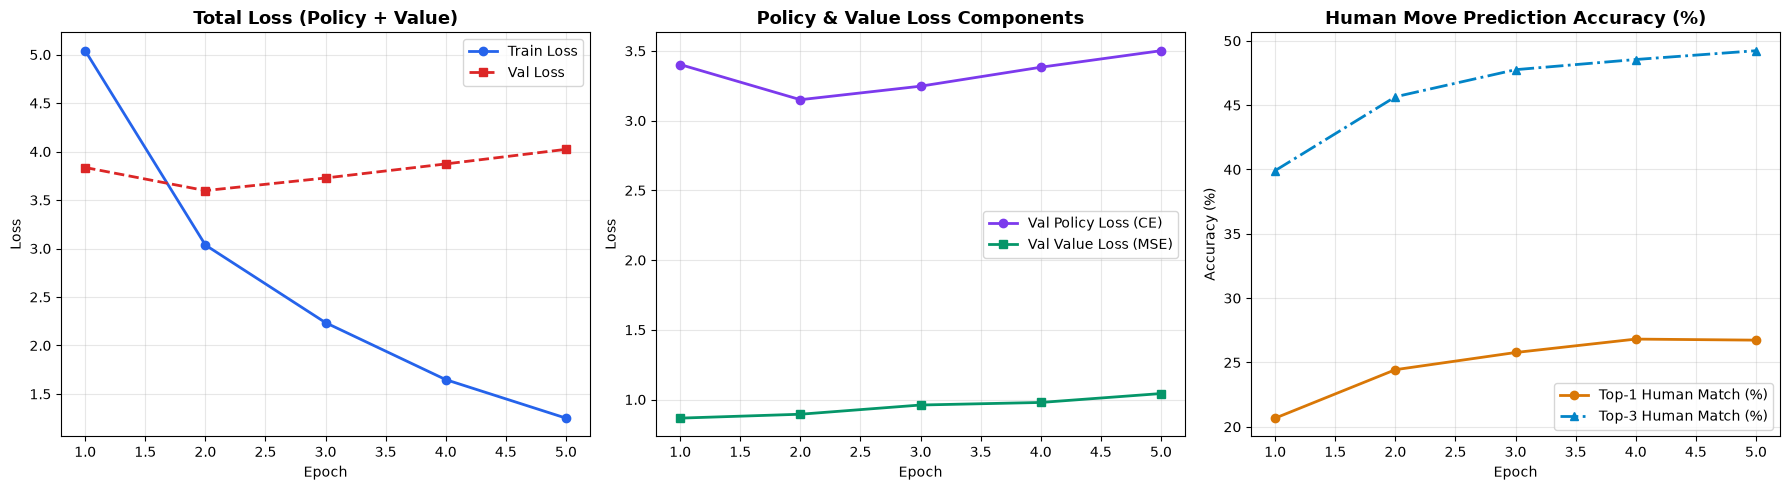

In [9]:
# ===========================================================================
# Step 6: Plot Training & Validation Curves
# ===========================================================================

if len(history["train_loss"]) > 0:
    fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(18, 5))
    epochs_range = range(1, len(history["train_loss"]) + 1)

    # 1. Total Loss
    ax1.plot(epochs_range, history["train_loss"], "o-", label="Train Loss", color="#2563EB", lw=2)
    ax1.plot(epochs_range, history["val_loss"], "s--", label="Val Loss", color="#DC2626", lw=2)
    ax1.set_title("Total Loss (Policy + Value)", fontsize=13, fontweight="bold")
    ax1.set_xlabel("Epoch")
    ax1.set_ylabel("Loss")
    ax1.grid(True, alpha=0.3)
    ax1.legend()

    # 2. Policy & Value Breakdown
    ax2.plot(epochs_range, history["val_p_loss"], "o-", label="Val Policy Loss (CE)", color="#7C3AED", lw=2)
    ax2.plot(epochs_range, history["val_v_loss"], "s-", label="Val Value Loss (MSE)", color="#059669", lw=2)
    ax2.set_title("Policy & Value Loss Components", fontsize=13, fontweight="bold")
    ax2.set_xlabel("Epoch")
    ax2.set_ylabel("Loss")
    ax2.grid(True, alpha=0.3)
    ax2.legend()

    # 3. Human Move Prediction Accuracy
    ax3.plot(epochs_range, history["val_top1"], "o-", label="Top-1 Human Match (%)", color="#D97706", lw=2)
    ax3.plot(epochs_range, history["val_top3"], "^-.", label="Top-3 Human Match (%)", color="#0284C7", lw=2)
    ax3.set_title("Human Move Prediction Accuracy (%)", fontsize=13, fontweight="bold")
    ax3.set_xlabel("Epoch")
    ax3.set_ylabel("Accuracy (%)")
    ax3.grid(True, alpha=0.3)
    ax3.legend()

    plt.tight_layout()
    plt.show()
else:
    print("Run the training loop in Step 5 first to display training curves.")

## 🔍 7. Interactive Position Analysis & Human Move Diagnostics

Now that the model is trained, we can analyze any chess board position (via FEN string or move sequence). The AI will:
1. Evaluate the win probability $v(s)$ from the active player's perspective.
2. Output the top human candidate moves with calibrated probability percentages.
3. Display the board in clean Unicode ASCII format.

In [10]:
# ===========================================================================
# Step 7: Interactive Position Evaluator Function
# ===========================================================================

def analyze_position(fen_or_board, top_k: int = 4):
    """
    Analyzes a position using the trained model and prints detailed human diagnostics.
    """
    board = chess.Board(fen_or_board) if isinstance(fen_or_board, str) else fen_or_board.copy()
    turn_str = "White" if board.turn == chess.WHITE else "Black"
    
    probs, val = model.evaluate_board(board, device)
    win_pct = (val + 1.0) / 2.0 * 100.0
    
    # Gather and rank legal moves
    scored_moves = []
    for idx in np.where(probs > 0)[0]:
        move = decode_move_index(idx, board.turn)
        p = float(probs[idx])
        scored_moves.append((move, p))
    scored_moves.sort(key=lambda x: x[1], reverse=True)
    
    print("=" * 60)
    print(f"♟️ POSITION EVALUATION (Active: {turn_str} to move)")
    print("=" * 60)
    print(board.unicode(borders=True))
    print("-" * 60)
    print(f"📊 Win Probability ({turn_str}) : {win_pct:.1f}% (Score: {val:+.3f})")
    print(f"💡 Top Human Candidate Moves:")
    for i, (m, p) in enumerate(scored_moves[:top_k], 1):
        san = board.san(m)
        bar = "█" * int(p * 30)
        print(f"   {i}. {san:<6} ({m.uci():<5}) : {p * 100:5.1f}%  {bar}")
    print("=" * 60 + "\n")


# Test Case 1: Italian Game Position
print("--- Test Case 1: Italian Game (1. e4 e5 2. Nf3 Nc6 3. Bc4) ---")
test_board = chess.Board()
for m in ["e2e4", "e7e5", "g1f3", "b8c6", "f1c4"]:
    test_board.push_san(m)
analyze_position(test_board)

# Test Case 2: Scholar's Mate Defense
print("--- Test Case 2: Defending Against Early Queen Attack (1. e4 e5 2. Qh5) ---")
defense_board = chess.Board("r1bqkbnr/pppp1ppp/2n5/4p2Q/2B1P3/8/PPPP1PPP/RNB1K1NR b KQkq - 3 3")
analyze_position(defense_board)

--- Test Case 1: Italian Game (1. e4 e5 2. Nf3 Nc6 3. Bc4) ---
♟️ POSITION EVALUATION (Active: Black to move)
  -----------------
8 |♜|⭘|♝|♛|♚|♝|♞|♜|
  -----------------
7 |♟|♟|♟|♟|⭘|♟|♟|♟|
  -----------------
6 |⭘|⭘|♞|⭘|⭘|⭘|⭘|⭘|
  -----------------
5 |⭘|⭘|⭘|⭘|♟|⭘|⭘|⭘|
  -----------------
4 |⭘|⭘|♗|⭘|♙|⭘|⭘|⭘|
  -----------------
3 |⭘|⭘|⭘|⭘|⭘|♘|⭘|⭘|
  -----------------
2 |♙|♙|♙|♙|⭘|♙|♙|♙|
  -----------------
1 |♖|♘|♗|♕|♔|⭘|⭘|♖|
  -----------------
   a b c d e f g h
------------------------------------------------------------
📊 Win Probability (Black) : 50.7% (Score: +0.015)
💡 Top Human Candidate Moves:
   1. Nf6    (g8f6 ) :  30.9%  █████████
   2. Bc5    (f8c5 ) :  28.2%  ████████
   3. d6     (d7d6 ) :  14.8%  ████
   4. h6     (h7h6 ) :  10.3%  ███

--- Test Case 2: Defending Against Early Queen Attack (1. e4 e5 2. Qh5) ---
♟️ POSITION EVALUATION (Active: Black to move)
  -----------------
8 |♜|⭘|♝|♛|♚|♝|♞|♜|
  -----------------
7 |♟|♟|♟|♟|⭘|♟|♟|♟|
  -----------------
6 |⭘|⭘|♞|⭘|⭘|⭘|

## ⚔️ 8. Sparring Mode: Play Against Your Trained AI Coach

You can play a full sparring game against your trained model directly inside this notebook! You can play as White or Black, and the AI will reply using its human-calibrated policy network.

In [11]:
# ===========================================================================
# Step 8: Play a Friendly Sparring Game Against Your AI Coach
# ===========================================================================

def play_sparring_game(player_color=chess.WHITE, temperature=0.2):
    """
    Plays an interactive chess sparring game against the AI coach.
    Type 'quit' to end the game, or enter UCI moves (e.g. 'e2e4', 'e7e5').
    """
    board = chess.Board()
    print("=" * 60)
    print(" ♚ CHESS AI COACH SPARRING SESSION")
    print(f" You are playing as: {'White (First Move)' if player_color == chess.WHITE else 'Black'}")
    print(" Type your move in UCI format (e.g., 'e2e4', 'e7e5') or 'quit' to stop.")
    print("=" * 60)
    
    while not board.is_game_over():
        print(board.unicode(borders=True))
        
        if board.turn == player_color:
            # Human Turn
            legal_uci = [m.uci() for m in board.legal_moves]
            user_input = input(f"Your move ({', '.join(legal_uci[:8])}...): ").strip()
            if user_input.lower() in ["quit", "exit", "q"]:
                print("Game ended by user.")
                break
                
            try:
                move = chess.Move.from_uci(user_input)
                if move in board.legal_moves:
                    board.push(move)
                else:
                    print(f"❌ Illegal move: {user_input}. Try again.")
                    continue
            except Exception:
                print("❌ Invalid format. Please enter moves like 'e2e4'.")
                continue
        else:
            # AI Turn
            print("\n🤖 AI Coach is thinking...")
            probs, val = model.evaluate_board(board, device)
            
            # Sample move with temperature
            legal_indices = np.where(probs > 0)[0]
            p_vals = probs[legal_indices] ** (1.0 / max(0.01, temperature))
            p_vals = p_vals / np.sum(p_vals)
            chosen_idx = np.random.choice(legal_indices, p=p_vals)
            
            ai_move = decode_move_index(chosen_idx, board.turn)
            ai_san = board.san(ai_move)
            print(f"🤖 AI plays: {ai_san} ({ai_move.uci()}) [Eval: {val:+.2f}]")
            board.push(ai_move)
            
    print("\n" + "=" * 60)
    print(" GAME OVER")
    print(f" Result: {board.result()}")
    print("=" * 60)


# Uncomment the line below to play a live sparring game in the notebook:
# play_sparring_game(player_color=chess.WHITE)